<a href="https://colab.research.google.com/github/ramanask/Product-Review-Sentiment-Analysis/blob/main/Product_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas scikit-learn nltk matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
data = {
    "review": [
        "This product is excellent",
        "Worst purchase ever",
        "Very good quality",
        "Not satisfied",
        "Amazing experience",
        "Poor build quality"
    ],
    "rating": [5, 1, 4, 2, 5, 1]
}

df = pd.DataFrame(data)
df.to_csv("product_reviews.csv", index=False)


In [6]:
df = pd.read_csv("/content/product_reviews.csv")
df.head()


,review,rating
0,This product is excellent,5
1,Worst purchase ever,1
2,Very good quality,4
3,Not satisfied,2
4,Amazing experience,5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  6 non-null      object
 1   rating  6 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [8]:
df = df[df['rating'] != 3]

df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)
df[['rating', 'sentiment']].head()


,rating,sentiment
0,5,1
1,1,0
2,4,1
3,2,0
4,5,1


In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)


In [10]:
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head()


,review,clean_review
0,This product is excellent,product excellent
1,Worst purchase ever,worst purchase ever
2,Very good quality,good quality
3,Not satisfied,satisfied
4,Amazing experience,amazing experience


In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [14]:
y_pred = model.predict(X_test)


In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.5


In [16]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


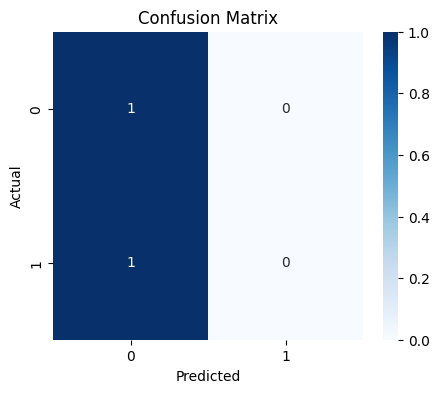

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [18]:
feature_names = tfidf.get_feature_names_out()


In [19]:
coefficients = model.feature_log_prob_

# Positive class (1)
top_positive = np.argsort(coefficients[1])[-20:]
# Negative class (0)
top_negative = np.argsort(coefficients[0])[-20:]

print("Top Positive Words:")
for i in top_positive:
    print(feature_names[i])

print("\nTop Negative Words:")
for i in top_negative:
    print(feature_names[i])


Top Positive Words:
build
ever
excellent
product
poor
worst
satisfied
purchase
quality
amazing
experience
good

Top Negative Words:
amazing
ever
excellent
experience
product
good
worst
purchase
quality
build
poor
satisfied
